In [1]:
from pyulog import ULog
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.style.use('dark_background')

LOG_PATH = '../data/logs/log_0_2026-6-11-14-25-29.ulg'
ulog = ULog(LOG_PATH)

pos = ulog.get_dataset('vehicle_local_position')
t = pos.data['timestamp']
duration = (t[-1] - t[0]) / 1e6

bat = ulog.get_dataset('battery_status')
t_bat = (bat.data['timestamp'] - bat.data['timestamp'][0]) / 1e6
pct = bat.data['remaining'] * 100

BATTERY_FAIL_T = 33.2

print(f"Log loaded ✅")
print(f"Duration: {duration:.1f}s ({duration/60:.1f} min)")
print(f"Battery start: {pct[0]:.1f}% → end: {pct[-1]:.1f}%")

Log loaded ✅
Duration: 66.3s (1.1 min)
Battery start: 100.0% → end: 0.0%


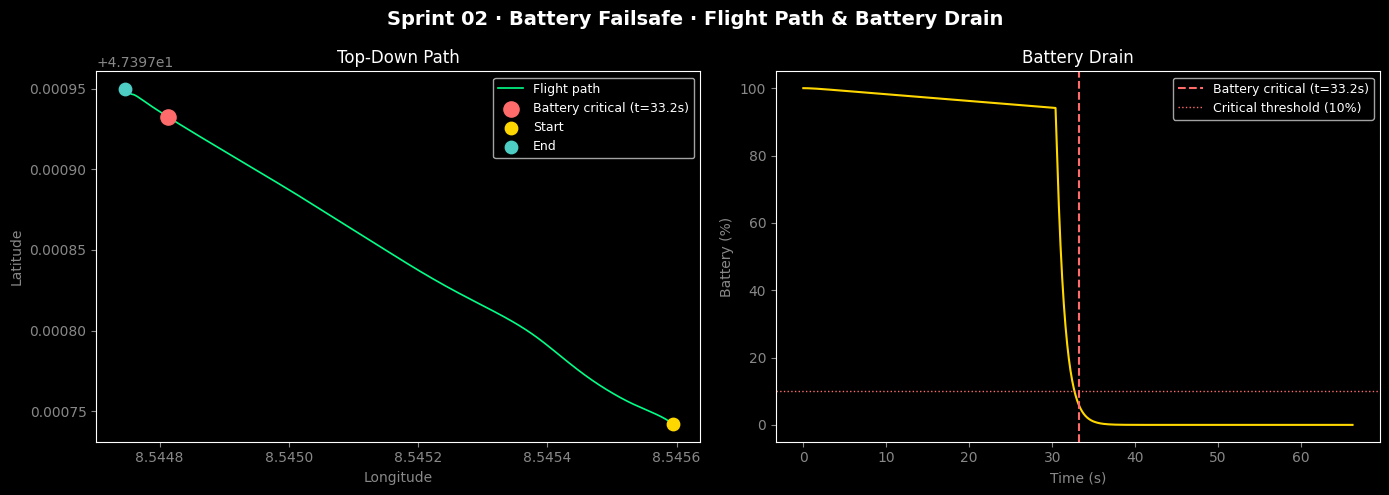

Flight path saved ✅


In [3]:
gps = ulog.get_dataset('vehicle_global_position')
t_gps = (gps.data['timestamp'] - gps.data['timestamp'][0]) / 1e6
lat = gps.data['lat']
lon = gps.data['lon']
alt = gps.data['alt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sprint 02 · Battery Failsafe · Flight Path & Battery Drain',
             color='white', fontsize=14, fontweight='bold')

# Top-down path
ax1 = axes[0]
ax1.plot(lon, lat, color='#00FF88', linewidth=1.2, label='Flight path')
idx_fs = np.argmin(np.abs(t_gps - BATTERY_FAIL_T))
ax1.scatter(lon[idx_fs], lat[idx_fs], color='#FF6B6B', s=120, zorder=5, label=f'Battery critical (t={BATTERY_FAIL_T}s)')
ax1.scatter(lon[0], lat[0], color='#FFD700', s=80, zorder=5, label='Start')
ax1.scatter(lon[-1], lat[-1], color='#4ECDC4', s=80, zorder=5, label='End')
ax1.set_xlabel('Longitude', color='#888888')
ax1.set_ylabel('Latitude', color='#888888')
ax1.set_title('Top-Down Path', color='white')
ax1.legend(fontsize=9)
ax1.tick_params(colors='#888888')

# Battery drain
ax2 = axes[1]
ax2.plot(t_bat, pct, color='#FFD700', linewidth=1.5)
ax2.axvline(x=BATTERY_FAIL_T, color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'Battery critical (t={BATTERY_FAIL_T}s)')
ax2.axhline(y=10, color='#FF6B6B', linestyle=':', linewidth=1.0, label='Critical threshold (10%)')
ax2.set_xlabel('Time (s)', color='#888888')
ax2.set_ylabel('Battery (%)', color='#888888')
ax2.set_title('Battery Drain', color='white')
ax2.legend(fontsize=9)
ax2.tick_params(colors='#888888')

plt.tight_layout()
plt.savefig('../data/flight_path_failsafe_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Flight path saved ✅")

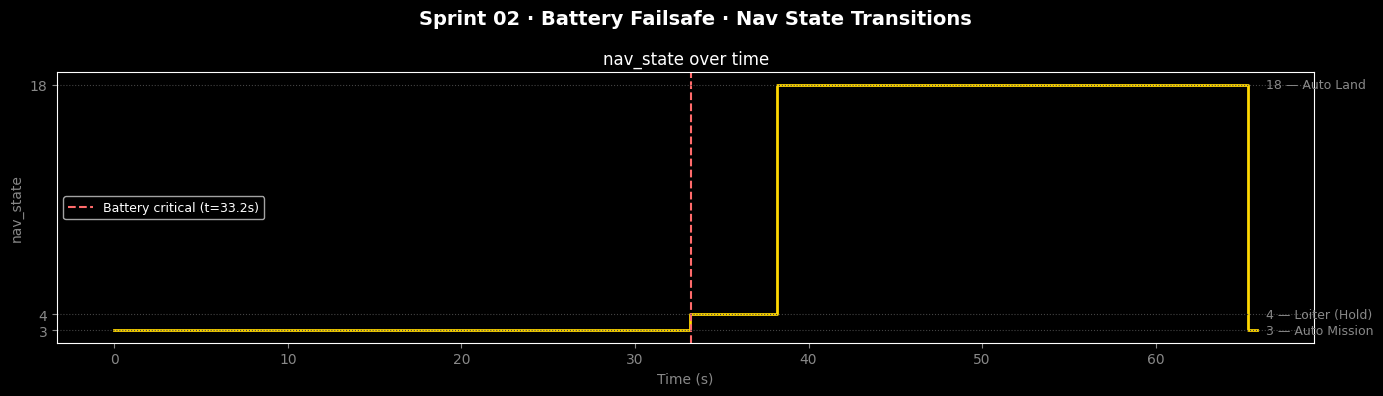

Nav state plot saved ✅


In [4]:
vs = ulog.get_dataset('vehicle_status')
t_vs = (vs.data['timestamp'] - vs.data['timestamp'][0]) / 1e6
nav = vs.data['nav_state']

nav_labels = {3: 'Auto Mission', 4: 'Loiter (Hold)', 18: 'Auto Land'}

fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle('Sprint 02 · Battery Failsafe · Nav State Transitions',
             color='white', fontsize=14, fontweight='bold')

ax.step(t_vs, nav, color='#FFD700', linewidth=2, where='post')
ax.axvline(x=BATTERY_FAIL_T, color='#FF6B6B', linestyle='--', linewidth=1.5, label=f'Battery critical (t={BATTERY_FAIL_T}s)')

for state, label in nav_labels.items():
    ax.axhline(y=state, color='#444444', linestyle=':', linewidth=0.8)
    ax.text(t_vs[-1] + 0.5, state, f'{state} — {label}', color='#888888', fontsize=9, va='center')

ax.set_yticks(list(nav_labels.keys()))
ax.set_yticklabels([str(k) for k in nav_labels.keys()], color='#888888')
ax.set_xlabel('Time (s)', color='#888888')
ax.set_ylabel('nav_state', color='#888888')
ax.set_title('nav_state over time', color='white')
ax.tick_params(colors='#888888')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/nav_state_failsafe_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Nav state plot saved ✅")

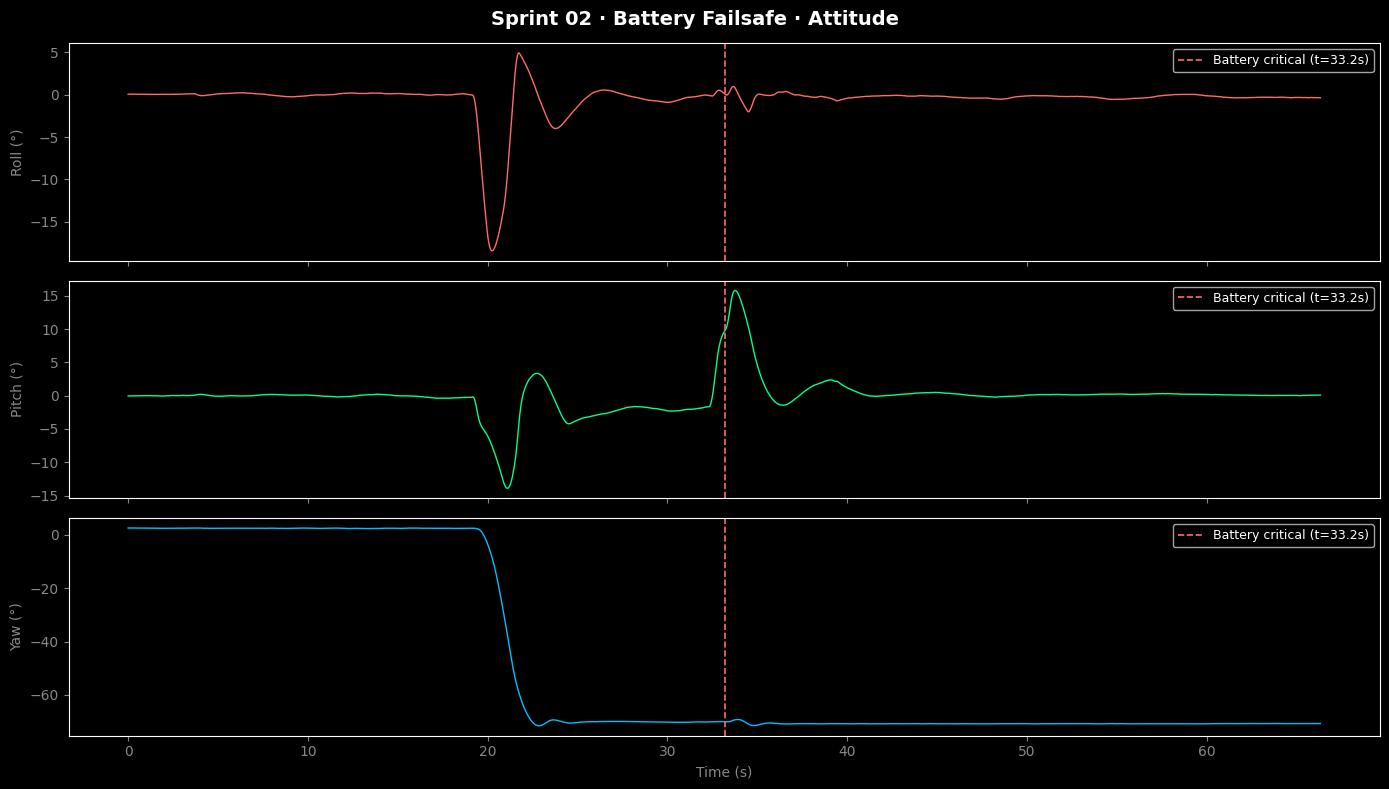

Attitude plot saved ✅


In [5]:
att = ulog.get_dataset('vehicle_attitude')
t_att = (att.data['timestamp'] - att.data['timestamp'][0]) / 1e6
q0, q1, q2, q3 = att.data['q[0]'], att.data['q[1]'], att.data['q[2]'], att.data['q[3]']

roll  = np.degrees(np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1**2 + q2**2)))
pitch = np.degrees(np.arcsin(np.clip(2*(q0*q2 - q3*q1), -1, 1)))
yaw   = np.degrees(np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2**2 + q3**2)))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Sprint 02 · Battery Failsafe · Attitude',
             color='white', fontsize=14, fontweight='bold')

for ax, data, label, color in zip(axes,
                                   [roll, pitch, yaw],
                                   ['Roll (°)', 'Pitch (°)', 'Yaw (°)'],
                                   ['#FF6B6B', '#00FF88', '#00BFFF']):
    ax.plot(t_att, data, color=color, linewidth=1.0)
    ax.axvline(x=BATTERY_FAIL_T, color='#FF6B6B', linestyle='--', linewidth=1.2, label=f'Battery critical (t={BATTERY_FAIL_T}s)')
    ax.set_ylabel(label, color='#888888')
    ax.tick_params(colors='#888888')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Time (s)', color='#888888')
plt.tight_layout()
plt.savefig('../data/attitude_failsafe_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attitude plot saved ✅")

In [6]:
nav_changes = []
prev = None
for t_, n in zip(t_vs, nav):
    if n != prev:
        nav_changes.append((t_, int(n)))
        prev = n

loiter_t   = next(t for t, n in nav_changes if n == 4)
land_t     = next(t for t, n in nav_changes if n == 18)
landed_t   = next(t for t, n in nav_changes if n == 3 and t > land_t)

print("=" * 55)
print("  SPRINT 02 · BATTERY FAILSAFE — MISSION SUMMARY")
print("=" * 55)
print(f"  Log file      : log_0_2026-6-11-14-25-29.ulg")
print(f"  Duration      : {duration:.1f}s ({duration/60:.1f} min)")
print(f"  Battery inject: t={BATTERY_FAIL_T:.1f}s  (failure battery off)")
print(f"  Hold (Loiter) : t={loiter_t:.1f}s  nav_state=4 (5s hold)")
print(f"  Auto Land     : t={land_t:.1f}s  nav_state=18")
print(f"  Landed        : t={landed_t:.1f}s")
print(f"  Reaction time : {loiter_t - BATTERY_FAIL_T:.1f}s")
print(f"  Battery drain : 100% → 0%")
print("=" * 55)
print("  Failsafe type : Emergency battery → Auto Land")
print("  Injection cmd : failure battery off (PX4 SITL CLI)")
print("  Hold period   : 5s loiter before descend")
print("  Outcome       : Controlled landing ✅")
print("=" * 55)

  SPRINT 02 · BATTERY FAILSAFE — MISSION SUMMARY
  Log file      : log_0_2026-6-11-14-25-29.ulg
  Duration      : 66.3s (1.1 min)
  Battery inject: t=33.2s  (failure battery off)
  Hold (Loiter) : t=33.2s  nav_state=4 (5s hold)
  Auto Land     : t=38.2s  nav_state=18
  Landed        : t=65.3s
  Reaction time : -0.0s
  Battery drain : 100% → 0%
  Failsafe type : Emergency battery → Auto Land
  Injection cmd : failure battery off (PX4 SITL CLI)
  Hold period   : 5s loiter before descend
  Outcome       : Controlled landing ✅
